# OEFENING: Lineaire Regressie met SciKit-Learn

Deze oefening hoort bij sessie 1 van de opleiding inzake regressieanalyse.

© 2023 Olivier Claerbout. Alle rechten voorbehouden.

We zagen hoe we een zeer eenvoudige beste fit-lijn konden creëren, maar laten we nu ons toolbox aanzienlijk uitbreiden om te beginnen nadenken over de overwegingen van overfitting, underfitting, model-evaluatie, en ook meerdere kenmerken!

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data


Deze voorbeeldgegevens tonen de verkoop (in duizenden eenheden) voor een bepaald product in functie van reclamebudgetten (in duizenden dollars) voor TV, radio en krantenmedia.

**TAAK: Lees de data (Advertising.csv) in en bekijk de eerste rijen.**

In [2]:
df_ad = pd.read_csv("data/Advertising.csv")
df_ad.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [8]:
df_ad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


### Uitbreiding

Voorheen hebben we nagegaan of er een relatie is tussen de total spend en de sales.  NU willen we de invloed van elk advertentiekanaal apart meten.  

Start met de onderlinge relatie tussen de verschillende advertentiekanalen te visualiseren.

### Multiple Features (N-Dimensional) / Meervoudige Lineaire Regressie

In [4]:
# relatie tussen de features...
df_cm = df_ad.corr()
df_cm 


,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


<Axes: >

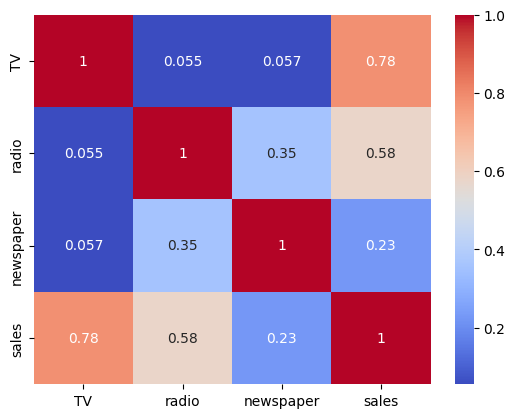

In [6]:
sns.heatmap(df_cm, cmap="coolwarm", annot=True)

**TAAK: Splits de dataset op in features X en targets y**

In [14]:
# Opsplitsen in features en targets
features = list(df_ad.columns[:3])
print(features)
X = df_ad[features].values
y= df_ad['sales'].values

['TV', 'radio', 'newspaper']


### Train | Test Split

from sklearn.model_selection import ...

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [ ]:
# Ga na hoeveel items er in de initiële dataset zitten, 
# en hoeveel er in de train en test set zitten.
print(f"Original: {df_ad.shape[0]=}")
print(f"Split: {X_train.shape[0]=}, {X_test.shape[0]=}")

Original: df_ad.shape[0]=200
Split: X_train.shape[0]=150, X_test.shape[0]=50


## Maken van het model (de Estimator)

#### Importeer de model class van de model family

In [30]:
from sklearn.linear_model import LinearRegression

#### Maak een instantie van het model met de parameters

In [31]:
estimator = LinearRegression()

### Fit/Train het Model op de training data

**Enkel op de training data fitten om een eerlijke evaluatie van de performantie later mogelijk te maken!**

In [32]:
estimator.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## TOT HIER VOOR DEEL 1 VAN DE OEFENING 

### Voorspel nu de sales waarden voor de test set

In [ ]:
test_pred = estimator.predict(X_test)
#test_pred = np.round(estimator.predict(X_test)).astype(int) - what for?

In [ ]:
# Importeer de performance metrics van sklearn.metrics (MAE, MSE)
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

In [52]:
print(f"MAE = {mean_absolute_error(test_pred, y_test):.2f} (MAPE = {100 * mean_absolute_percentage_error(test_pred, y_test):.1f} %)")
print(f"MSE = {mean_squared_error(test_pred, y_test):.2f} (RMSE = {np.sqrt(mean_squared_error(test_pred, y_test)):.2f})")
print("R² Score:", r2_score(test_pred, y_test))

MAE = 1.40 (MAPE = 14.1 %)
MSE = 2.88 (RMSE = 1.70)
R² Score: 0.8843196200174289


In [42]:
# we willen deze resultaten vergelijken met het gemiddelde van de dataset:
df_ad['sales'].mean()

np.float64(14.0225)

#### Is dit resultaat goed?

R² close to 1 → estimator catches most of the variability (good fit)
MAE is close to the average of the dataset → not bqd?
